# Errori di arrotondamento e aritmetica floating-point

Rappresentazione dei numeri reali, standard IEEE 754, propagazione degli errori e progettazione di formule numericamente stabili.


In [258]:
import math
import struct
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=16, suppress=False)

## Parte I — Rappresentazione floating-point


### Richiamo preliminare: sistemi di numerazione in base 10 e in base 2

Un sistema di numerazione **posizionale** rappresenta un numero mediante cifre il cui valore dipende sia dalla cifra stessa sia dalla posizione occupata. Se la base è $\beta$, le posizioni a sinistra della virgola corrispondono alle potenze $\beta^0,\beta^1,\beta^2,\ldots$, mentre quelle a destra corrispondono a $\beta^{-1},\beta^{-2},\ldots$.

Nel sistema decimale, cioè in base $10$, le cifre possibili sono $0,1,\ldots,9$. Per esempio,

$$
(325.47)_{10}
=
3\cdot10^2+2\cdot10^1+5\cdot10^0+4\cdot10^{-1}+7\cdot10^{-2}.
$$

Nel sistema binario, cioè in base $2$, le sole cifre disponibili sono $0$ e $1$. Per esempio,

$$
(101.101)_2
=
1\cdot2^2+0\cdot2^1+1\cdot2^0
+1\cdot2^{-1}+0\cdot2^{-2}+1\cdot2^{-3}
=5.625.
$$

Le regole sono quindi le stesse in entrambe le basi: cambia soltanto la base delle potenze e l'insieme delle cifre ammesse. I computer usano prevalentemente la base $2$ perché i due valori $0$ e $1$ possono essere associati in modo naturale a due stati fisici distinti dei circuiti elettronici.


### 1. Rappresentazione binaria normalizzata

Un numero reale non nullo può essere scritto idealmente come

$$
x=\pm(1.d_1d_2d_3\cdots)_2\times 2^e.
$$

In questa rappresentazione distinguiamo tre elementi:

- **Segno:** il simbolo $\pm$ indica se il numero è positivo o negativo.
- **Significando o mantissa:** la sequenza $(1.d_1d_2d_3\cdots)_2$ contiene le cifre binarie significative.
- **Esponente:** il valore $e$ determina l’ordine di grandezza e quindi la posizione della virgola binaria.

**Esempio:**

$$
\begin{aligned}
-(1.101)_2\times 2^1
&=-\left(1\cdot2^0+1\cdot2^{-1}+0\cdot2^{-2}+1\cdot2^{-3}\right)2^1\\
&=-\left(1+\frac{1}{2}+\frac{0}{4}+\frac{1}{8}\right)2\\
&=-\left(1+\frac{1}{2}+\frac{1}{8}\right)2\\
&=-(1.625)2\\
&=-3.25.
\end{aligned}
$$

La **normalizzazione** comporta che:

- la **prima cifra significativa** deve essere diversa da zero;
- in **base $2$**, la prima cifra di un numero normalizzato è necessariamente $1$;
- questo primo $1$ può essere lasciato **implicito**, cioè non deve essere memorizzato;
- il **bit implicito** così ottenuto permette di guadagnare un bit di precisione.

Non tutti i numeri reali hanno una rappresentazione binaria finita:

- una **frazione razionale** ha un’espansione binaria finita soltanto se, ridotta ai minimi termini, il suo denominatore è una potenza di $2$;
- il numero $1/8=0.001_2$ è quindi **rappresentabile esattamente**;
- il numero $1/10$, invece, richiede **infinite cifre binarie** e deve essere approssimato.

Il termine **floating-point**, cioè *virgola mobile*, richiama la notazione scientifica:

- la **posizione della virgola** non è fissata una volta per tutte;
- l’**esponente** sposta la virgola binaria e consente di rappresentare ordini di grandezza differenti;
- un’espansione ideale può contenere **infinite cifre**, mentre la memoria di un computer è finita;
- <mark>il computer deve quindi conservare un **numero prefissato di cifre significative** e limitare l’**intervallo degli esponenti**.</mark>

Il passaggio dal numero reale alla sua rappresentazione finita conduce ai **sistemi floating-point** introdotti nella sezione seguente.

In [259]:
value = -(1 + 1/2 + 1/8) * 2
print(value)

-3.25


### 2. Sistemi floating-point

Un sistema floating-point generale è descritto da quattro parametri:

$$
(\beta,t,L,U),
$$

dove:

- $\beta$ è la base;
- $t$ è la precisione;
- $L$ è il minimo esponente;
- $U$ è il massimo esponente.

Un numero normalizzato ha forma

$$
\pm
(d_0.d_1d_2\cdots d_{t-1})_{\beta}
\times \beta^e,
$$

con

$$
d_0\neq 0,
\qquad
L\le e\le U.
$$

I quattro parametri controllano aspetti diversi:

- la base $\beta$ determina le cifre disponibili;
- la precisione $t$ determina quanti dettagli relativi si conservano;
- l'intervallo $[L,U]$ determina quali ordini di grandezza sono rappresentabili.

Se per il momento consideriamo soltanto i numeri normalizzati diversi da zero, **il più piccolo numero positivo è**

$$
x_{\min}=\beta^L,
$$

mentre **il più grande è**

$$
x_{\max}=(\beta-\beta^{1-t})\beta^U.
$$

Con la convenzione adottata, per ogni valore dell’esponente sono possibili $(\beta-1)\beta^{t-1}$ diverse sequenze di $t$ cifre significative normalizzate e positive.

 Il sistema contiene quindi un insieme finito di valori, non una versione “compressa” dell'intera retta reale. Più avanti vedremo che lo standard IEEE 754 aggiunge anche valori speciali molto vicini a zero, i numeri subnormali.


### 3. Troncamento e arrotondamento

Poiché un sistema floating-point conserva soltanto $t$ cifre significative, un numero reale deve essere sostituito da uno dei valori effettivamente rappresentabili. Indichiamo con

$$
\mathrm{fl}(x)
$$

il numero floating-point assegnato al valore reale $x$. La notazione $\mathrm{fl}$, che useremo anche in seguito, significa quindi “risultato rappresentato o calcolato in aritmetica floating-point”.

Due strategie elementari sono:

- **troncamento:** si eliminano tutte le cifre successive alle prime $t$;
- **arrotondamento:** si sceglie il numero rappresentabile più vicino a $x$.

Esempio in base 10 con $t=3$:

| Numero | Troncato | Arrotondato |
|---:|---:|---:|
| 5.672 | 5.67 | 5.67 |
| 5.677 | 5.67 | 5.68 |
| 5.695 | 5.69 | 5.70 |

L'arrotondamento dimezza, nel caso peggiore, l'errore massimo rispetto al troncamento. Resta però da decidere che cosa fare quando $x$ si trova **esattamente a metà** fra i due floating-point più vicini, come nella terza riga della tabella: entrambi hanno la stessa distanza da $x$. Lo standard IEEE 754 usa normalmente la regola **round to nearest, ties to even**, cioè “arrotonda al più vicino e, in caso di parità, scegli quello pari”.

In un esempio decimale con una sola cifra dopo la virgola, $1.25$ è equidistante da $1.2$ e $1.3$: si sceglie $1.2$ perché la sua ultima cifra conservata, $2$, è pari. Analogamente, $1.35$ viene arrotondato a $1.4$, perché fra $3$ e $4$ la cifra pari è $4$. Nel sistema binario la stessa regola sceglie, fra i due candidati, quello il cui ultimo bit conservato è $0$. In questo modo i casi a metà non vengono arrotondati sistematicamente sempre verso l'alto o sempre verso il basso.

<div style="
    padding: 18px 22px;
    margin: 16px 0;
    border-left: 5px solid #4a90e2;
    border-radius: 6px;
    background-color: rgba(74, 144, 226, 0.10);
">

<h3 style="margin-top: 0;">💡 Nota — Cifre di guardia</h3>

Le **guard digits**, o **cifre di guardia**, sono cifre aggiuntive conservate temporaneamente durante un calcolo floating-point.

Non fanno parte del risultato finale, ma servono a stabilire come arrotondarlo correttamente.

Supponiamo, per esempio, di poter memorizzare soltanto tre cifre significative e di ottenere temporaneamente

$$
1.2351.
$$

Per decidere se memorizzare $1.23$ oppure $1.24$, è necessario conoscere almeno la cifra successiva, cioè $5$. Questa cifra aggiuntiva permette di scegliere l’arrotondamento corretto:

$$
1.2351 \longrightarrow 1.24.
$$

Nei sistemi conformi allo standard IEEE 754 si utilizzano generalmente tre informazioni aggiuntive:

- **guard bit:** è il primo bit successivo a quelli che saranno memorizzati;
- **round bit:** è il bit immediatamente successivo al guard bit;
- **sticky bit:** indica se almeno uno degli altri bit eliminati è diverso da zero.

Questi bit permettono di arrotondare il risultato come se l’operazione fosse stata eseguita esattamente e il risultato fosse stato arrotondato una sola volta alla precisione disponibile.

In sintesi:

- le cifre di guardia aumentano temporaneamente la precisione dei calcoli intermedi;


### 4. Unità di arrotondamento

L’**unità di arrotondamento**, indicata con $\eta$, misura il massimo errore relativo che può essere introdotto quando un numero reale viene sostituito dal floating-point più vicino. Essa descrive quindi la precisione intrinseca del sistema: più $\eta$ è piccola, più accurata è la rappresentazione dei numeri.

Ricordiamo che:

- $\mathrm{fl}(x)$ indica il valore floating-point assegnato al numero reale $x$;
- $\beta$ è la **base** del sistema;
- $t$ è il numero di **cifre significative** disponibili.

Per un sistema floating-point con arrotondamento al più vicino, l’unità di arrotondamento è

$$
\eta=\frac{1}{2}\beta^{1-t}.
$$

Per ogni numero normalizzato non nullo che appartiene all’intervallo delle grandezze rappresentabili vale

$$
\frac{|x-\mathrm{fl}(x)|}{|x|}\le \eta.
$$

In questa formula:

- $|x-\mathrm{fl}(x)|$ è l’**errore assoluto di rappresentazione**;
- $\frac{|x-\mathrm{fl}(x)|}{|x|}$ è l’**errore relativo di rappresentazione**;
- $\eta$ costituisce un limite superiore per tale errore relativo.

La stessa proprietà può essere riscritta nella forma

$$
\mathrm{fl}(x)=x(1+\delta),
\qquad |\delta|\le\eta,
$$

dove $\delta$ rappresenta la piccola **perturbazione relativa** introdotta dall’arrotondamento. Il valore memorizzato può quindi essere interpretato come il valore esatto $x$ moltiplicato per un fattore molto vicino a $1$.

Questa stima riguarda i **numeri normalizzati** compresi nell’intervallo rappresentabile. Il comportamento dei valori eccezionalmente grandi o piccoli verrà descritto più avanti, dopo avere introdotto la struttura dello standard IEEE 754.

Nel formato **double precision** definito dallo standard IEEE 754:

- la base è $\beta=2$;
- la precisione effettiva è $t=53$ bit significativi;
- l’unità di arrotondamento è

$$
\eta
=
\frac{1}{2}2^{1-53}
=
2^{-53}
\approx 1.1\times10^{-16}.
$$

#### Unità di arrotondamento ed `eps`

La terminologia non è sempre uniforme. In NumPy, `eps` indica la distanza tra $1$ e il floating-point immediatamente successivo. Per `float64` si ha

$$
\mathrm{eps}=2^{-52}.
$$

L’unità di arrotondamento per l’arrotondamento al più vicino è invece

$$
\eta=\frac{\mathrm{eps}}{2}=2^{-53}.
$$

Espressioni come **machine epsilon**, **precisione di macchina** e **unità di arrotondamento** possono quindi essere utilizzate con convenzioni differenti. È sempre opportuno verificare la definizione adottata nel software o nel documento che si sta consultando.


In [260]:
eps = np.finfo(float).eps
eta = eps / 2

print("eps NumPy =", eps)
print("eta = eps/2 =", eta)
print("2^-53 =", 2.0**(-53))
print("1 + eta == 1 ?", 1 + eta == 1)
print("1 + eps > 1 ?", 1 + eps > 1)

eps NumPy = 2.220446049250313e-16
eta = eps/2 = 1.1102230246251565e-16
2^-53 = 1.1102230246251565e-16
1 + eta == 1 ? True
1 + eps > 1 ? True


#### `eps` e unità di arrotondamento

Per `float64`, NumPy restituisce

$$
\mathrm{eps}=2^{-52},
$$

che è la distanza fra $1$ e il floating-point successivo. L'unità di arrotondamento definita è

$$
\eta=\frac{\mathrm{eps}}{2}=2^{-53}.
$$

Il numero $1+\eta$ cade esattamente a metà fra due floating-point. Con la regola ties-to-even viene arrotondato a $1$, mentre $1+\mathrm{eps}$ è il vicino successivo e risulta strettamente maggiore di $1$.


### 5. Single precision e double precision

Lo **standard IEEE 754** stabilisce come rappresentare i numeri floating-point e come eseguire le operazioni aritmetiche fondamentali. Grazie a uno standard comune, uno stesso formato ha significato coerente su processori e linguaggi diversi.

La parola **precisione** indica quanti bit vengono riservati all'intera rappresentazione e, di conseguenza, quante cifre significative e quali ordini di grandezza sono disponibili. I due formati binari più comuni sono:

- **single precision**, che occupa 32 bit ed è usata quando sono importanti il risparmio di memoria e la velocità;
- **double precision**, che occupa 64 bit e offre una precisione e un intervallo di grandezze maggiori. È il formato normalmente usato dal tipo `float` di Python e da `numpy.float64`.

La disposizione dei campi può essere rappresentata schematicamente nel modo seguente. Le larghezze grafiche non sono in scala.

**Single precision, 32 bit**

<table style="border-collapse: collapse; width: 100%; text-align: center;">
<tr>
<td style="border: 2px solid #555; padding: 10px; width: 12%;"><b>segno</b><br>1 bit</td>
<td style="border: 2px solid #555; padding: 10px; width: 28%;"><b>esponente</b><br>8 bit</td>
<td style="border: 2px solid #555; padding: 10px; width: 60%;"><b>frazione</b><br>23 bit</td>
</tr>
</table>

**Double precision, 64 bit**

<table style="border-collapse: collapse; width: 100%; text-align: center;">
<tr>
<td style="border: 2px solid #555; padding: 10px; width: 8%;"><b>segno</b><br>1 bit</td>
<td style="border: 2px solid #555; padding: 10px; width: 22%;"><b>esponente</b><br>11 bit</td>
<td style="border: 2px solid #555; padding: 10px; width: 70%;"><b>frazione</b><br>52 bit</td>
</tr>
</table>

Per i numeri **normalizzati**, la prima cifra binaria significativa è sempre $1$ e può essere lasciata implicita. Per questo 23 bit memorizzati nella frazione forniscono 24 bit significativi in single precision, mentre 52 bit memorizzati ne forniscono 53 in double precision. In termini decimali corrispondono a circa 7 e 16 cifre significative. Ciò non significa che ogni numero stampato con 16 cifre sia esatto: significa che l'errore relativo di una singola rappresentazione double normalizzata è controllato alla scala di $10^{-16}$.

#### Numeri subnormali

La forma normalizzata richiede una prima cifra uguale a $1$ e produce quindi un più piccolo numero positivo normalizzato. Senza un accorgimento ulteriore rimarrebbe un intervallo vuoto fra questo valore e zero. IEEE 754 usa i **numeri subnormali** per riempire gradualmente parte di tale intervallo.

In un numero subnormale l'esponente memorizzato è tutto zero e la prima cifra significativa non è più il bit implicito $1$: il numero ha una forma del tipo

$$
\pm(0.d_1d_2\cdots d_{t-1})_2\times 2^{e_{\min}}.
$$

*I subnormali permettono quindi di rappresentare valori più piccoli del minimo normalizzato e rendono graduale il passaggio verso zero. Il prezzo è una precisione relativa via via minore, perché diminuendo il numero diminuiscono anche le cifre significative effettivamente disponibili.*


In [261]:
info32 = np.finfo(np.float32)
info64 = np.finfo(np.float64)

print("float32")
print("eps:", info32.eps)
print("eta:", info32.eps/2)
print("max:", info32.max)
print("tiny:", info32.tiny)

print("\nfloat64")
print("eps:", info64.eps)
print("eta:", info64.eps/2)
print("max:", info64.max)
print("tiny:", info64.tiny)

float32
eps: 1.1920929e-07
eta: 5.9604645e-08
max: 3.4028235e+38
tiny: 1.1754944e-38

float64
eps: 2.220446049250313e-16
eta: 1.1102230246251565e-16
max: 1.7976931348623157e+308
tiny: 2.2250738585072014e-308


#### Come leggere `finfo`

`eps` descrive la risoluzione relativa vicino a $1$; `tiny` è il più piccolo numero **normalizzato** positivo; `max` è il più grande numero finito. Tra zero e `tiny` esistono i subnormali, che estendono l'intervallo rappresentabile ma hanno meno cifre significative. Il confronto mostra perché `float32` occupa meno memoria ma offre un margine molto più ridotto sia in precisione sia nell'intervallo degli esponenti.


### 6. Errore di arrotondamento apparentemente casuale

Gli errori di arrotondamento hanno spesso un aspetto irregolare.

Consideriamo

$$
g(t)=e^{-t}(\sin(2\pi t)+2).
$$

Confrontiamo la valutazione in double precision con la stessa quantità memorizzata in single precision.

L'aspetto “quasi casuale” nasce dal fatto che il segno e la dimensione dell'errore cambiano quando il valore esatto attraversa i confini fra numeri rappresentabili. Non bisogna però concludere che gli errori siano variabili casuali indipendenti: l'aritmetica floating-point è deterministica e può produrre pattern sistematici. La lettura corretta del grafico è che l'errore resta alla scala prevista dall'unità di arrotondamento, pur oscillando rapidamente.


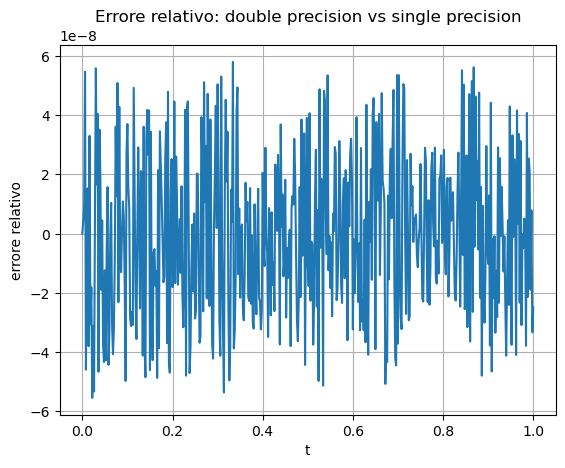

max errore relativo / eta_single = 0.9737441196931675


In [262]:
t = np.linspace(0, 1, 501)

tt64 = np.exp(-t) * (np.sin(2*np.pi*t) + 2)
tt32 = tt64.astype(np.float32).astype(np.float64)

round_err = (tt64 - tt32) / tt64

plt.figure()
plt.plot(t, round_err)
plt.title("Errore relativo: double precision vs single precision")
plt.xlabel("t")
plt.ylabel("errore relativo")
plt.grid(True)
plt.show()

print("max errore relativo / eta_single =", np.max(np.abs(round_err)) / (np.finfo(np.float32).eps/2))

#### Lettura dell'errore relativo

I valori in single precision vengono convertiti nuovamente in double soltanto per misurare la differenza: la conversione non recupera le cifre già perdute. L'ampiezza tipica dell'errore relativo è dell'ordine di $10^{-8}$, coerente con l'unità di arrotondamento della single precision. Le oscillazioni rapide non rappresentano rumore di misura, ma i diversi arrotondamenti deterministici lungo la funzione campionata.


### 7. Distribuzione dei numeri floating-point

I numeri floating-point non sono uniformemente distribuiti.

La distanza assoluta fra due numeri consecutivi cresce con la grandezza del numero.

Invece, la distanza relativa resta circa controllata dall'unità di arrotondamento.

Tra $2^e$ e $2^{e+1}$, cioè all'interno della stessa **binade**, la distanza fra numeri normalizzati consecutivi è costante e vale circa

$$
\operatorname{ulp}(x)=2^{e-(t-1)}.
$$

Passando alla binade successiva, la distanza raddoppia. Per questo il sistema offre una precisione approssimativamente costante in senso relativo, non in senso assoluto. Il grafico di un sistema giocattolo rende visibile questa geometria.


In [263]:
values = [1.0, 10.0, 1e6, 1e16]

for x in values:
    next_x = np.nextafter(x, np.inf)
    spacing = next_x - x
    print(f"x={x:.1e}, spacing={spacing:.3e}, spacing relativo={spacing/x:.3e}")

x=1.0e+00, spacing=2.220e-16, spacing relativo=2.220e-16
x=1.0e+01, spacing=1.776e-15, spacing relativo=1.776e-16
x=1.0e+06, spacing=1.164e-10, spacing relativo=1.164e-16
x=1.0e+16, spacing=2.000e+00, spacing relativo=2.000e-16


#### Distanza assoluta e distanza relativa

`np.nextafter(x, np.inf)` restituisce il primo floating-point maggiore di $x$. La differenza `next_x - x` cresce con $x$, mentre il rapporto tra questa differenza e $x$ resta vicino a `eps`. Attorno a $10^{16}$ la spaziatura è già dell'ordine delle unità: aggiungere $1$ può quindi non modificare affatto il valore memorizzato.


### 8. Sistema floating-point giocattolo

Costruiamo il sistema

$$
(\beta,t,L,U)=(2,3,-2,3).
$$

I numeri positivi normalizzati sono ottenuti da mantisse tra

$$
1.00_2
$$

e

$$
1.11_2
$$

e da esponenti da $-2$ a $3$.

Per ogni esponente ci sono quattro mantisse positive: $1.00_2$, $1.01_2$, $1.10_2$ e $1.11_2$. I punti sono equidistanti all'interno di ciascuna binade, ma la distanza raddoppia quando l'esponente aumenta. Senza numeri subnormali rimane inoltre un intervallo vuoto fra $0$ e il più piccolo numero normalizzato. Nei sistemi reali i subnormali riempiono gradualmente parte di questo intervallo e rendono l'underflow meno brusco.


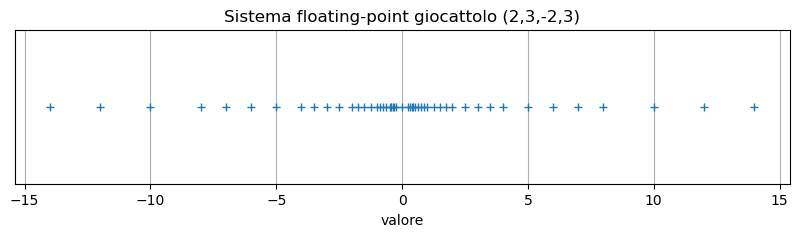

In [264]:
def toy_floats(beta=2, t=3, L=-2, U=3):
    mantissas = []
    for frac in range(beta**(t-1)):
        mantissas.append(1 + frac / beta**(t-1))

    nums = []
    for m in mantissas:
        for e in range(L, U+1):
            nums.append(m * beta**e)

    nums = np.array(sorted(nums))
    return np.concatenate([-nums[::-1], [0.0], nums])

nums = toy_floats()

plt.figure(figsize=(10, 2))
plt.plot(nums, np.zeros_like(nums), "+")
plt.yticks([])
plt.grid(True)
plt.title("Sistema floating-point giocattolo (2,3,-2,3)")
plt.xlabel("valore")
plt.show()

#### Geometria del sistema giocattolo

Il grafico non deve essere letto come una distribuzione statistica. Ogni gruppo di punti corrisponde a un esponente; all'interno del gruppo la spaziatura è uniforme, poi raddoppia passando alla scala successiva. L'addensamento vicino a zero esprime una precisione relativa quasi costante. Il vuoto centrale ricorda che, nel modello normalizzato privo di subnormali, nessun valore positivo è rappresentabile tra zero e $\beta^L$.


## Parte II — Lo standard IEEE 754 e i valori speciali


### 9. Struttura di un numero in double precision

Un numero double occupa 64 bit, divisi nei tre campi già anticipati:

| Campo | Numero di bit | Funzione |
|---|---:|---|
| segno | 1 | stabilisce se il numero è positivo o negativo |
| esponente | 11 | determina l'ordine di grandezza |
| frazione | 52 | contiene le cifre binarie significative dopo il punto |

Consideriamo anzitutto un numero **normalizzato**.

**1. Segno.** Il bit di segno è indicato con $s$. Se $s=0$ il numero è positivo; se $s=1$ è negativo. Il fattore che descrive entrambi i casi è $(-1)^s$.

**2. Frazione e significando.** Se i bit della frazione sono $d_1,d_2,\ldots,d_{52}$, essi rappresentano il numero

$$
f=d_1 2^{-1}+d_2 2^{-2}+\cdots+d_{52}2^{-52},
\qquad 0\le f<1.
$$

Poiché nei normalizzati la prima cifra binaria è sempre $1$, essa non viene memorizzata e si ricostruisce la parte significativa come $1+f$. Questa parte è chiamata **significando**; viene spesso detta anche mantissa.

**3. Esponente e bias.** Gli 11 bit dell'esponente vengono letti come un intero non negativo $b$. Gli esponenti reali devono però poter essere sia positivi sia negativi. Per evitare di dedicare un ulteriore bit al segno dell'esponente, si memorizza il valore traslato di una quantità fissa, detta **bias**. Nel formato double il bias vale $1023$, quindi

$$
e=b-1023.
$$

Per esempio, $b=1023$ codifica $e=0$, $b=1022$ codifica $e=-1$ e $b=1024$ codifica $e=1$. Il bias permette così di memorizzare esponenti di entrambi i segni usando un normale intero binario non negativo.

Combinando i tre campi si ottiene

$$
x=(-1)^s(1+f)2^e.
$$

Questa formula non è una convenzione aggiunta dall'esterno: ricostruisce direttamente il segno, il significando binario normalizzato e la potenza di $2$ codificati nei 64 bit.

Non tutti i valori di $b$ sono usati per i numeri normalizzati. Se il campo esponente è tutto zero, il bit iniziale del significando non è implicito e si rappresentano lo zero o i numeri subnormali. Se il campo esponente è tutto uno, si rappresentano $\pm\infty$ o NaN. Restano così, per i numeri normalizzati double, gli esponenti reali da $-1022$ a $1023$.


### 10. Overflow, underflow, infinito e NaN

**Overflow:** il risultato è troppo grande per essere rappresentato. Spesso produce `inf`.

**Underflow:** il risultato è troppo piccolo. Può produrre un numero subnormale o zero.

**NaN:** Not a Number, prodotto da operazioni indefinite come $0/0$.

Questi valori speciali permettono ai programmi di proseguire o segnalare problemi in modo controllato.

L'overflow è spesso più distruttivo dell'underflow: un valore finito diventa infinito e può contaminare molti passaggi successivi. L'underflow graduale, invece, può ancora produrre un piccolo numero subnormale e conservare parte dell'informazione. Se il valore scende ulteriormente, viene arrotondato a zero.

I valori speciali seguono regole precise: per esempio un numero finito diviso per zero può produrre $\pm\infty$, mentre operazioni indeterminate come $0/0$ o $\infty-\infty$ producono NaN. Un confronto con NaN è falso anche quando lo si confronta con se stesso; per individuarlo si usano funzioni come `np.isnan`.


In [265]:
info64 = np.finfo(np.float64)

print("Massimo numero finito:", info64.max)
print("Minimo numero finito:", info64.min)
print("Minimo positivo normalizzato:", info64.tiny)
print("Minimo positivo subnormale:", info64.smallest_subnormal)
print()

x = np.float64(1e308)
print("overflow:", x * 10)

small = np.float64(1e-308)
print("underflow verso zero:", small / 1e20)

a = np.array([0.0])
print("0/0:", a/a)

print("inf - inf:", np.inf - np.inf)

Massimo numero finito: 1.7976931348623157e+308
Minimo numero finito: -1.7976931348623157e+308
Minimo positivo normalizzato: 2.2250738585072014e-308
Minimo positivo subnormale: 5e-324

overflow: inf
underflow verso zero: 0.0
0/0: [nan]
inf - inf: nan


/var/folders/fn/ldzxtqdx50q1q6160qq33gtm0000gn/T/ipykernel_71653/892903259.py:10: RuntimeWarning: overflow encountered in scalar multiply
  print("overflow:", x * 10)
/var/folders/fn/ldzxtqdx50q1q6160qq33gtm0000gn/T/ipykernel_71653/892903259.py:16: RuntimeWarning: invalid value encountered in divide
  print("0/0:", a/a)


#### Perché non bisogna ignorare i valori speciali

NumPy emette avvisi ma continua il calcolo secondo le regole IEEE 754. Questo comportamento è utile nei calcoli vettoriali, ma richiede controlli espliciti: un `inf` può propagarsi e un NaN può rendere falsi i confronti successivi. In un algoritmo robusto si stabilisce se intercettare subito questi valori, sostituirli oppure restituire un messaggio diagnostico.


## Parte III — Cancellazione e formule stabili


### 11. Cancellazione numerica

La **cancellazione numerica** si manifesta quando si sottraggono due numeri quasi uguali. Se

$$
z=x-y
$$

e $x\approx y$, molte cifre iniziali di $x$ e $y$ coincidono e si eliminano nella sottrazione. Il risultato $z$ è molto più piccolo dei due operandi e dipende soprattutto dalle loro ultime cifre, che sono anche quelle maggiormente influenzate dall'arrotondamento.

Supponiamo che il computer non disponga dei valori esatti $x$ e $y$, ma dei valori leggermente perturbati $\tilde{x}=x+e_x$ e $\tilde{y}=y+e_y$. Il risultato calcolato, prima di considerare l'ulteriore arrotondamento della sottrazione, è

$$
\tilde{z}=\tilde{x}-\tilde{y}
=(x-y)+(e_x-e_y).
$$

L'errore assoluto nel risultato è quindi

$$
|\tilde{z}-z|=|e_x-e_y|\le |e_x|+|e_y|.
$$

Questa quantità può essere piccola in valore assoluto. Per misurare però quante cifre significative restano in $z$, dobbiamo dividerla per la grandezza del risultato esatto:

$$
\frac{|\tilde{z}-z|}{|z|}
\le
\frac{|e_x|+|e_y|}{|x-y|}.
$$

Se $x-y$ è molto piccolo, il denominatore è piccolo e il rapporto può diventare grande. Per esempio, errori assoluti dell'ordine di $10^{-16}$ negli operandi possono essere trascurabili quando $x$ e $y$ sono dell'ordine di $1$, ma diventano rilevanti se la loro differenza è dell'ordine di $10^{-15}$. La sottrazione non crea necessariamente un grande errore assoluto: amplifica l'errore **relativo** e rende visibili le incertezze presenti nelle ultime cifre degli operandi.


In [266]:
x = 1.000000000000001
y = 1.000000000000000
z = x - y

print("x =", format(x, ".17f"))
print("y =", format(y, ".17f"))
print("z =", format(z, ".17e"))

x = 1.00000000000000111
y = 1.00000000000000000
z = 1.11022302462515654e-15


#### Come leggere l'esempio Python

Il codice sceglie due numeri dell'ordine di $1$ che differiscono soltanto nelle ultime cifre disponibili in double precision:

$$
x=1.000000000000001,
\qquad
y=1.000000000000000.
$$

La stampa con 17 cifre mostra i valori realmente memorizzati, non soltanto quelli digitati nel codice. In aritmetica decimale ci aspetteremmo una differenza pari a $10^{-15}$; il computer restituisce invece un valore vicino a $1.110223\times10^{-15}$, legato alla spaziatura dei floating-point attorno a $1$.

L'esempio vuole mostrare che, dopo la cancellazione delle molte cifre comuni, il risultato è formato quasi interamente dalle ultime cifre della rappresentazione. L'errore assoluto resta minuscolo, ma la differenza non conserva tutte le cifre relative che la scrittura decimale iniziale potrebbe far immaginare.


### 12. Differenza di seni in forma stabile

Una derivata può essere approssimata mediante la formula alle **differenze finite in avanti**

$$
f'(x_0)\approx\frac{f(x_0+h)-f(x_0)}{h}.
$$

Se $f(x)=\sin(x)$ e $h$ è molto piccolo, il numeratore

$$
\sin(x_0+h)-\sin(x_0)
$$

sottrae due valori quasi uguali e può soffrire di cancellazione. Per riscriverlo usiamo l'identità

$$
\sin(\phi)-\sin(\psi)
=
2\cos\left(\frac{\phi+\psi}{2}\right)
\sin\left(\frac{\phi-\psi}{2}\right).
$$

Ponendo $\phi=x_0+h$ e $\psi=x_0$ otteniamo

$$
\sin(x_0+h)-\sin(x_0)
=
2\cos\left(x_0+\frac{h}{2}\right)
\sin\left(\frac{h}{2}\right).
$$

Dividendo per $h$ si ricava la forma stabile della differenza finita:

$$
\frac{\sin(x_0+h)-\sin(x_0)}{h}
=
\underbrace{\cos\left(x_0+\frac{h}{2}\right)}_{\text{primo fattore}}
\underbrace{\frac{\sin(h/2)}{h/2}}_{\text{secondo fattore}}.
$$

Il **secondo fattore** è dunque il rapporto $\sin(h/2)/(h/2)$ e tende a $1$ quando $h\to0$. Il primo fattore tende invece a $\cos(x_0)$, che è proprio la derivata di $\sin(x)$ in $x_0$. La forma riscritta evita di ottenere la piccola quantità al numeratore sottraendo due seni quasi uguali. Per argomenti estremamente piccoli, una funzione di libreria specializzata per $\sin z/z$ può migliorare ulteriormente il calcolo.


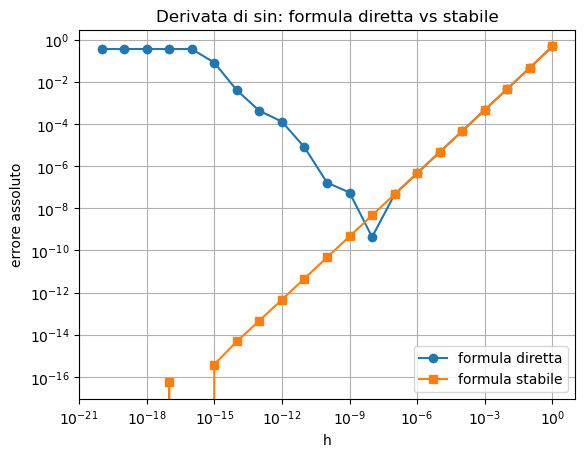

In [267]:
def derivative_sin_naive(x0, h):
    return (math.sin(x0+h) - math.sin(x0)) / h

def derivative_sin_stable(x0, h):
    return 2 * math.cos(x0 + h/2) * math.sin(h/2) / h

x0 = 1.2
true_value = math.cos(x0)

hs = 10.0 ** np.arange(-20, 1)
err_naive = np.array([abs(true_value - derivative_sin_naive(x0, hh)) for hh in hs])
err_stable = np.array([abs(true_value - derivative_sin_stable(x0, hh)) for hh in hs])

plt.figure()
plt.loglog(hs, err_naive, marker="o", label="formula diretta")
plt.loglog(hs, err_stable, marker="s", label="formula stabile")
plt.title("Derivata di sin: formula diretta vs stabile")
plt.xlabel("h")
plt.ylabel("errore assoluto")
plt.grid(True, which="both")
plt.legend()
plt.show()

#### Confronto fra forma diretta e forma stabile

Per passi moderati le due formule coincidono entro l'errore di arrotondamento. Quando $h$ diventa molto piccolo, la differenza diretta dei seni perde cifre significative; la forma trigonometrica conserva invece il fattore piccolo come $\sin(h/2)$ senza ottenerlo per sottrazione. Il confronto con $\cos(x_0)$ rende visibile il guadagno di accuratezza.


### 13. Esempio: $\sqrt{x+1}-\sqrt{x}$

Per $x$ grande, la formula diretta

$$
\sqrt{x+1}-\sqrt{x}
$$

sottrae due numeri quasi uguali.

Moltiplicando e dividendo per il coniugato:

$$
\sqrt{x+1}-\sqrt{x}
=
\frac{1}{\sqrt{x+1}+\sqrt{x}}.
$$

La seconda formula è numericamente più stabile.

Le due espressioni sono identiche in aritmetica esatta ma non sul computer. Nella prima forma, le cifre comuni delle due radici si cancellano. Nella seconda compaiono soltanto somme e divisioni fra quantità della stessa scala, e non si perde informazione significativa. Questa è una strategia generale: usare un'identità algebrica per eliminare una sottrazione pericolosa.


In [268]:
def sqrt_diff_naive(x):
    return math.sqrt(x + 1) - math.sqrt(x)

def sqrt_diff_stable(x):
    return 1 / (math.sqrt(x + 1) + math.sqrt(x))

for x in [1e5, 1e10, 1e15, 1e20]:
    naive = sqrt_diff_naive(x)
    stable = sqrt_diff_stable(x)
    print(f"x={x:.1e}")
    print("  diretta =", naive)
    print("  stabile =", stable)
    print("  differenza =", abs(naive - stable))

x=1.0e+05
  diretta = 0.001581134877255863
  stabile = 0.0015811348772568783
  differenza = 1.0152469143154264e-15
x=1.0e+10
  diretta = 4.999994416721165e-06
  stabile = 4.999999999875e-06
  differenza = 5.583153835188651e-12
x=1.0e+15
  diretta = 1.862645149230957e-08
  stabile = 1.5811388300841893e-08
  differenza = 2.8150631914676777e-09
x=1.0e+20
  diretta = 0.0
  stabile = 5e-11
  differenza = 5e-11


#### Che cosa mostra l'esperimento

All'aumentare di $x$, le due radici quadrate diventano sempre più vicine. La formula diretta può infine restituire zero perché i due operandi vengono arrotondati allo stesso numero. La formula razionalizzata rimane positiva e conserva l'ordine di grandezza corretto, circa $1/(2\sqrt{x})$.


### 14. La funzione $\sinh(x)$ vicino a zero

La formula

$$
\sinh(x)=\frac{e^x-e^{-x}}{2}
$$

può soffrire di cancellazione per $x$ vicino a zero.

Lo sviluppo di Taylor è

$$
\sinh(x)=x+\frac{x^3}{6}+\frac{x^5}{120}+\cdots.
$$

Per $|x|$ piccolo, pochi termini possono essere più accurati.

Non esiste una formula migliore per ogni valore di $x$. Per $x$ moderato la definizione esponenziale è adeguata; vicino a zero una serie o una funzione di libreria come `expm1`, progettata per calcolare $e^x-1$, evita la cancellazione. Una libreria robusta sceglie internamente la rappresentazione più accurata in base alla regione del dominio e tronca la serie quando il termine successivo è inferiore alla tolleranza richiesta.


In [269]:
def sinh_direct(x):
    return 0.5 * (math.exp(x) - math.exp(-x))

def sinh_taylor3(x):
    return x + x**3 / 6

for x in [1e-1, 1e-5, 1e-10, 1e-15]:
    direct = sinh_direct(x)
    tay = sinh_taylor3(x)
    exact = math.sinh(x)
    print(f"x={x:.1e}")
    print("  errore formula diretta =", abs(direct - exact))
    print("  errore Taylor =", abs(tay - exact))

x=1.0e-01
  errore formula diretta = 6.938893903907228e-17
  errore Taylor = 8.335317736030134e-08
x=1.0e-05
  errore formula diretta = 4.5644911461639737e-17
  errore Taylor = 0.0
x=1.0e-10
  errore formula diretta = 8.274037096265818e-18
  errore Taylor = 0.0
x=1.0e-15
  errore formula diretta = 5.4711873393898636e-17
  errore Taylor = 0.0


#### Scelta della formula in base alla scala

La serie cubica è accurata soltanto quando i termini trascurati, a partire da $x^5/120$, sono piccoli rispetto alla precisione richiesta. Per valori non piccoli deve essere preferita una formula di libreria. L'esempio non suggerisce di sostituire sempre `sinh` con tre termini di Taylor, ma di evitare una sottrazione instabile nella regione in cui esiste un'approssimazione locale controllata.


## Parte IV — Calcolo stabile delle radici di un'equazione quadratica


### 15. Formula standard e problema di cancellazione

Per

$$
x^2-2bx+c=0
$$

le radici sono

$$
x_{1,2}=b\pm\sqrt{b^2-c}.
$$

Se $b^2$ è molto più grande di $c$, una delle due formule contiene una sottrazione tra quantità quasi uguali.

Si può usare la relazione

$$
x_1x_2=c
$$

per calcolare in modo stabile la radice piccola.

Supponiamo per esempio $b>0$. La radice $b+\sqrt{b^2-c}$ è calcolata senza cancellazione, mentre $b-\sqrt{b^2-c}$ è la differenza di due numeri quasi uguali. Si calcola quindi prima la radice grande

$$
x_1=b+\sqrt{b^2-c}
$$

e poi la radice piccola usando il prodotto delle radici:

$$
x_2=\frac{c}{x_1}.
$$

Per $b<0$ si sceglie il segno opposto. Il principio è sempre lo stesso: calcolare direttamente la combinazione che somma quantità concordi e ricavare l'altra radice da una relazione esatta.


In [270]:
def roots_standard_b(b, c):
    d = math.sqrt(b*b - c)
    return b + d, b - d

def roots_stable_b(b, c):
    d = math.sqrt(b*b - c)
    if b > 0:
        x1 = b + d
        x2 = c / x1
    else:
        x2 = b - d
        x1 = c / x2
    return x1, x2

b = 1e8
c = 1.0

x1s, x2s = roots_standard_b(b, c)
x1r, x2r = roots_stable_b(b, c)

print("standard:", x1s, x2s)
print("stabile :", x1r, x2r)
print("prodotto standard:", x1s*x2s)
print("prodotto stabile :", x1r*x2r)

standard: 200000000.0 0.0
stabile : 200000000.0 5e-09
prodotto standard: 0.0
prodotto stabile : 1.0


### 16. Equazione quadratica generale

Per

$$
ax^2+bx+c=0
$$

la formula standard è

$$
x_{1,2}
=
\frac{-b\pm\sqrt{b^2-4ac}}{2a}.
$$

Una forma più stabile usa

$$
q=-\frac{1}{2}\left(b+\mathrm{sign}(b)\sqrt{b^2-4ac}\right),
$$

poi

$$
x_1=\frac{q}{a},
\qquad
x_2=\frac{c}{q}.
$$

La scelta di `sign(b)` fa sì che in $q$ i due termini abbiano lo stesso segno, evitando la cancellazione. La formula richiede comunque controlli per casi particolari: $a=0$, discriminante negativo, $q=0$ e possibili overflow nel calcolo di $b^2-4ac$. Le implementazioni di produzione possono scalare i coefficienti o usare operazioni più robuste per il discriminante.

La stabilità numerica non consiste quindi nel sostituire meccanicamente una formula con un'altra, ma nel gestire in modo coerente tutti i rami del problema.


In [271]:
def quadratic_standard(a, b, c):
    if a == 0:
        return [-c/b] if b != 0 else []
    disc = b*b - 4*a*c
    if disc < 0:
        return []
    s = math.sqrt(disc)
    return [(-b + s)/(2*a), (-b - s)/(2*a)]

def quadratic_stable(a, b, c):
    if a == 0:
        return [-c/b] if b != 0 else []
    disc = b*b - 4*a*c
    if disc < 0:
        return []
    s = math.sqrt(disc)
    if b >= 0:
        q = -0.5 * (b + s)
    else:
        q = -0.5 * (b - s)

    x1 = q / a
    x2 = c / q if q != 0 else 0.0
    return [x1, x2]

cases = [
    (1.0, -1e8, 1.0),
    (1.0, 1e8, 1.0),
    (1.0, -2.0, 1e-12),
]

for a, b, c in cases:
    print("\nCaso:", a, b, c)
    print("standard:", quadratic_standard(a,b,c))
    print("stabile :", quadratic_stable(a,b,c))


Caso: 1.0 -100000000.0 1.0
standard: [100000000.0, 7.450580596923828e-09]
stabile : [100000000.0, 1e-08]

Caso: 1.0 100000000.0 1.0
standard: [-7.450580596923828e-09, -100000000.0]
stabile : [-100000000.0, -1e-08]

Caso: 1.0 -2.0 1e-12
standard: [1.9999999999995, 5.000444502911705e-13]
stabile : [1.9999999999995, 5.00000000000125e-13]


#### Verifica delle radici

Oltre a confrontare le due implementazioni, si possono usare le identità di Viète

$$
x_1+x_2=-\frac{b}{a},
\qquad
x_1x_2=\frac{c}{a}.
$$

Quando una radice è molto più piccola dell'altra, il prodotto è spesso un controllo più sensibile della piccola radice rispetto alla semplice sostituzione nel polinomio. Anche i controlli numerici devono però essere interpretati tenendo conto della scala dei coefficienti.


## Parte V — Progettazione di funzioni di libreria robuste


### 17. Norma euclidea e overflow

La norma euclidea è

$$
\|x\|_2=\sqrt{x_1^2+\cdots+x_n^2}.
$$

Una formula ingenua può generare overflow calcolando i quadrati, anche quando la norma finale è rappresentabile.

Per evitare il problema, si scala il vettore con

$$
s=\max_i |x_i|.
$$

Allora

$$
\|x\|_2
=
s\sqrt{\sum_i\left(\frac{x_i}{s}\right)^2}.
$$

Poiché $|x_i/s|\le1$, i quadrati nella somma scalata non possono andare in overflow. La moltiplicazione finale per $s$ ricostruisce la scala corretta. La stessa idea protegge anche dall'underflow quando le componenti sono molto piccole. Se $s=0$, il vettore è nullo e la norma deve essere restituita direttamente come zero.

Una funzione di libreria può usare strategie ancora più raffinate per sommare i quadrati, ma il ridimensionamento mostra già perché una formula matematicamente ovvia non è sempre una buona implementazione.


In [272]:
def norm2_naive(x):
    x = np.asarray(x, dtype=float) #Gli elementi vengono memorizzati come numeri floating-point anziché come interi
    return math.sqrt(np.sum(x*x))

def norm2_stable(x):
    x = np.asarray(x, dtype=float)
    s = np.max(np.abs(x))
    if s == 0:
        return 0.0
    y = x / s
    return s * math.sqrt(np.sum(y*y))

vectors = [
    np.array([3.0, 4.0]),
    np.array([1e200, 1.0]),
    np.array([1e-200, 1e-200]),
]

for v in vectors:
    print("v =", v)
    try:
        print("  naive:", norm2_naive(v))
    except Exception as e:
        print("  naive errore:", e)
    print("  stabile:", norm2_stable(v))
    print("  numpy:", np.linalg.norm(v))

v = [3. 4.]
  naive: 5.0
  stabile: 5.0
  numpy: 5.0
v = [1.e+200 1.e+000]
  naive: inf
  stabile: 1e+200
  numpy: inf
v = [1.e-200 1.e-200]
  naive: 0.0
  stabile: 1.414213562373095e-200
  numpy: 0.0


/var/folders/fn/ldzxtqdx50q1q6160qq33gtm0000gn/T/ipykernel_71653/496547588.py:3: RuntimeWarning: overflow encountered in multiply
  return math.sqrt(np.sum(x*x))


#### Risultato della norma scalata

Nel calcolo ingenuo i quadrati possono superare `float64.max` e produrre infinito, anche se la radice quadrata finale sarebbe rappresentabile. La versione scalata mantiene i rapporti $x_i/s$ nell'intervallo $[-1,1]$ e restituisce una norma finita. L'esempio mostra che evitare risultati intermedi estremi è una parte essenziale della progettazione numerica.


### 18. Varianza e cancellazione

La varianza può essere calcolata come

$$
s^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

dove $\bar{x}$ è la media, oppure come

$$
s^2=\frac{1}{n}\sum_{i=1}^{n}x_i^2-\bar{x}^2.
$$

La seconda formula può essere meno accurata se i dati sono grandi ma la varianza è piccola, perché sottrae due numeri quasi uguali.

Nella seconda formula, sia $\frac{1}{n}\sum x_i^2$ sia $\bar{x}^2$ possono essere dell'ordine di $10^{16}$, mentre la loro differenza è dell'ordine di $1$. Quasi tutte le cifre significative devono quindi cancellarsi. Gli errori di arrotondamento presenti nei due termini possono diventare più grandi della varianza stessa e produrre perfino un valore negativo.

La formula centrata in due passaggi è in genere molto più stabile. Quando i dati arrivano in streaming, si può usare l'algoritmo incrementale di Welford, che aggiorna media e somma degli scarti senza formare la differenza fra due quantità enormi.


In [273]:
# Crea un generatore di numeri casuali.
# Il valore 0 è il seme: usando sempre lo stesso seme si ottengono
# gli stessi numeri casuali, rendendo l'esperimento riproducibile.
rng = np.random.default_rng(0)

# rng.normal genera 100000 numeri estratti da una distribuzione normale:
# - media predefinita uguale a 0;
# - deviazione standard scale=1.0;
# - numero di valori size=100000.
#
# Aggiungendo 1e8, i dati vengono concentrati attorno a 100000000,
# pur mantenendo oscillazioni dell'ordine di 1.
data = 1e8 + rng.normal(scale=1.0, size=100000)

# np.mean calcola la media aritmetica degli elementi dell'array.
mean = np.mean(data)

var_stable = np.mean((data - mean)**2)
var_unstable = np.mean(data**2) - mean**2

print("varianza stabile:", var_stable)
print("formula alternativa:", var_unstable)
print("differenza:", var_unstable - var_stable)

varianza stabile: 1.000257024601711
formula alternativa: 2.0
differenza: 0.9997429753982889


#### Risultato della varianza

I dati sono concentrati attorno a $10^8$, ma le loro deviazioni dalla media sono dell'ordine di $1$. La formula a un passaggio sottrae due quantità dell'ordine di $10^{16}$ per ricavare un risultato dell'ordine di $1$: è una configurazione ideale per la cancellazione. La formula centrata conserva molte più cifre significative.


## Parte VI — Riepilogo finale


### Checklist dei concetti principali

Al termine della lezione dovreste saper spiegare:

1. come funziona una rappresentazione posizionale in base $10$ e in base $2$;
2. che cosa significa normalizzare un numero binario e perché il primo bit può essere implicito;
3. perché un computer deve rappresentare i numeri reali con un numero finito di cifre;
4. il significato dei parametri $(\beta,t,L,U)$ di un sistema floating-point;
5. la differenza fra troncamento e arrotondamento e la regola ties-to-even;
6. che cosa sono le cifre di guardia e la notazione $\mathrm{fl}(x)$;
7. che cosa misura l'unità di arrotondamento e come si distingue da `eps` di NumPy;
8. la struttura dei formati single e double precision;
9. la differenza fra numeri normalizzati e subnormali;
10. che cosa sono overflow, underflow, infinito e NaN;
11. perché la cancellazione può produrre un grande errore relativo;
12. come identità algebriche equivalenti possano condurre a formule numericamente più stabili.

### Glossario

**Floating-point:** rappresentazione a virgola mobile.

**Mantissa o significando:** parte significativa del numero floating-point; viene spesso chiamata anche mantissa.

**Bias dell'esponente:** costante sottratta all'esponente memorizzato per ottenere l'esponente reale.

**Numero subnormale:** numero molto vicino a zero rappresentato senza il bit iniziale implicito, con precisione relativa ridotta.

**$\mathrm{fl}(x)$:** valore floating-point assegnato al numero reale $x$.

**Esponente:** parte che determina l'ordine di grandezza.

**Unità di arrotondamento:** limite superiore tipico dell'errore relativo di rappresentazione.

**Cancellazione:** perdita di cifre significative nella sottrazione di numeri quasi uguali.

**Overflow:** risultato troppo grande per essere rappresentato.

**Underflow:** risultato troppo piccolo per essere rappresentato come normalizzato.

**NaN:** Not a Number.

